In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

This is an EDA about Renewable Energy in California. We are diving into questions that suggest at what optimal conditions does renewable energy rise such as with humidity, temperature, Wind Speed, etc.

The Questions we are going to be focusing on today are **5 Main Questions:**

1. Wind Speed
2. Humidity
3. Temperature
4. Solar Radiation (DHI, DNI, and GHI) across Multiple Seasons
5. What seasons are meant for solar or wind.

In [2]:
# Processing and Loading Data

dataset = pd.read_csv("Database.csv")
print(dataset.head())
print(dataset.info())

def process_data(data):
    data = data.copy()
    
    data.columns = data.columns.str.strip()
    data = data.dropna().drop_duplicates()

    data['Time'] = data['Time'].astype(str).str.strip()
    data['Time'] = pd.to_datetime(data['Time'], format='%Y-%m-%d-T%H:%M')
    return data

def average(data):
    df = data.set_index('Time').sort_index()
    num_cols = df.select_dtypes(include=['number']).columns
    
    daily = df[num_cols].resample('D').mean()
    monthly = daily.rolling(window=30, min_periods=15, center=True).mean()
    
    return monthly.reset_index()

processed_data = process_data(dataset)
monthly_data = average(processed_data)
print(processed_data.head())
print(processed_data.info())

           Time               Season  Day_of_the_week  DHI    DNI    GHI     \
0      0   2019-01-01-T00:00       1                1    0.0    0.0     0.0   
1      1   2019-01-01-T00:05       1                1    0.0    0.0     0.0   
2      2   2019-01-01-T00:10       1                1    0.0    0.0     0.0   
3      3   2019-01-01-T00:15       1                1    0.0    0.0     0.0   
4      4   2019-01-01-T00:20       1                1    0.0    0.0     0.0   

   Wind_speed          Humidity            Temperature            \
0                2.88              56.036                   1.82   
1                2.88              56.036                   1.82   
2                2.88              56.194                   1.78   
3                2.88              56.344                   1.74   
4                2.84              56.440                   1.72   

   PV_production  Wind_production  Electric_demand  
0              0             2810            22216  
1         

In [8]:
# Functions for modular usage:

def graph_data(data, dependent_var, units, ax=None):
    x_axis = data['Time']
    y_axis = data[f"{dependent_var}"]
    
    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 5))
        standalone = True
    else:
        standalone = False
        
    ax.plot(x_axis, y_axis, color='blue', linewidth=1)
    ax.set_title(f"{dependent_var.replace('_', ' ').title()} Over Time")
    ax.set_ylabel(f"{dependent_var.replace('_', ' ').title()} ({units})")
    ax.grid(True, linestyle='--', alpha=0.3)
    
    if standalone:
        ax.set_xlabel('Time')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
def get_correlation(var1, var2):
    return float(corr_matrix.loc[var1, var2])

Here is a Correlation Matrix diving into the connections between these weather conditions.

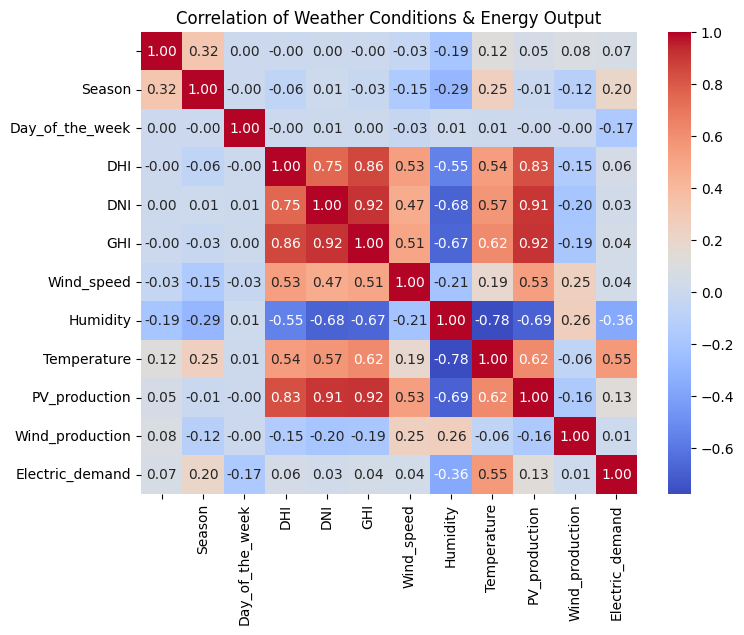

In [12]:
# Correlation Matrix

corr_matrix = processed_data.corr(numeric_only=True)

plt.figure(figsize=(8, 6))
# Exclude the 'Time' column for correlation
sns.heatmap(processed_data.drop(columns=['Time']).corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation of Weather Conditions & Energy Output")
plt.show()

**Question 1: How does Wind Speed affect Wind Power Usage?**

Correlation between Wind Speed and Wind Production: 0.24621372972887598


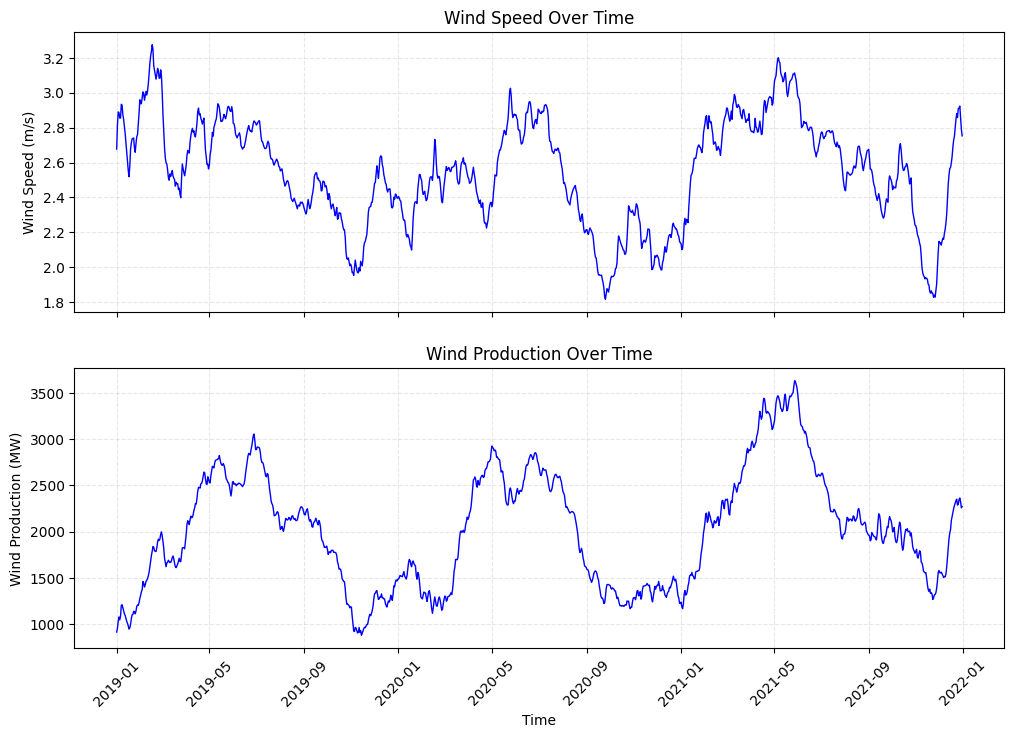

In [10]:
# Graphing
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(12, 8))

# Wind Speed Graph
graph_data(monthly_data, 'Wind_speed', 'm/s', ax=ax1)

# Wind Power Over Time Graph
graph_data(monthly_data, 'Wind_production', 'MW', ax=ax2)

plt.xticks(rotation=45)
ax2.set_xlabel('Time')

# Correlation Coefficient
print(f"Correlation between Wind Speed and Wind Production: {get_correlation('Wind_speed', 'Wind_production')}")

There is a positive correlation value (0.24) between Wind Speed and Wind Production, showing how when wind speed increases, wind productions increase, albeit at a weaker rate.

**Question 2: How does Humidity affect both Solar and Wind power?**

Correlation between Humidity and PV Production: -0.6905601176237899
Correlation between Humidity and Wind Production: 0.2620684871604189


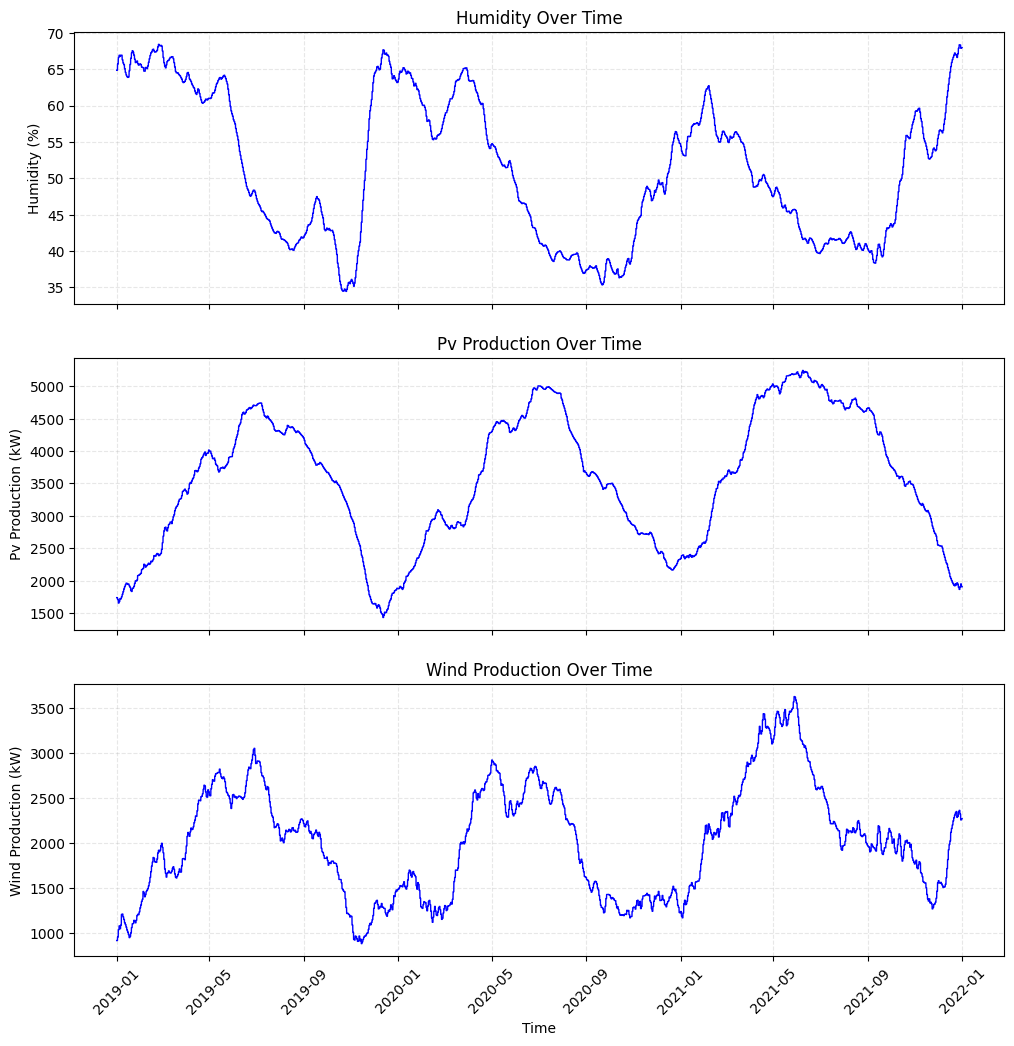

In [63]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, sharex=True, figsize=(12, 12))

# Wind Speed Graph
graph_data(monthly_data, 'Humidity', '%', ax=ax1)

# Solar Power Graph
graph_data(monthly_data, 'PV_production', 'kW', ax=ax2)

# Wind Power Graph
graph_data(monthly_data, 'Wind_production', 'kW', ax=ax3)

plt.xticks(rotation=45)
ax3.set_xlabel('Time');

# Correlation Coefficients
print(f"Correlation between Humidity and PV Production: {get_correlation('Humidity', 'PV_production')}")
print(f"Correlation between Humidity and Wind Production: {get_correlation('Humidity', 'Wind_production')}")

According to the correlation matrix, it shows a negative correlation value (-0.69) between Humidity and Solar Production (PV), showing how water vapor can damage solar panels. In contrast, it shows a positive correlation value (0.26) between Humidity and Wind Production, demonstrating how humidity helps with wind production.

**Question 3 How much of an impact does Temperature have on Renewables?**

Correlation between Temperature and PV Production: 0.6249319684165529
Correlation between Temperature and Wind Production: -0.06225903482755038


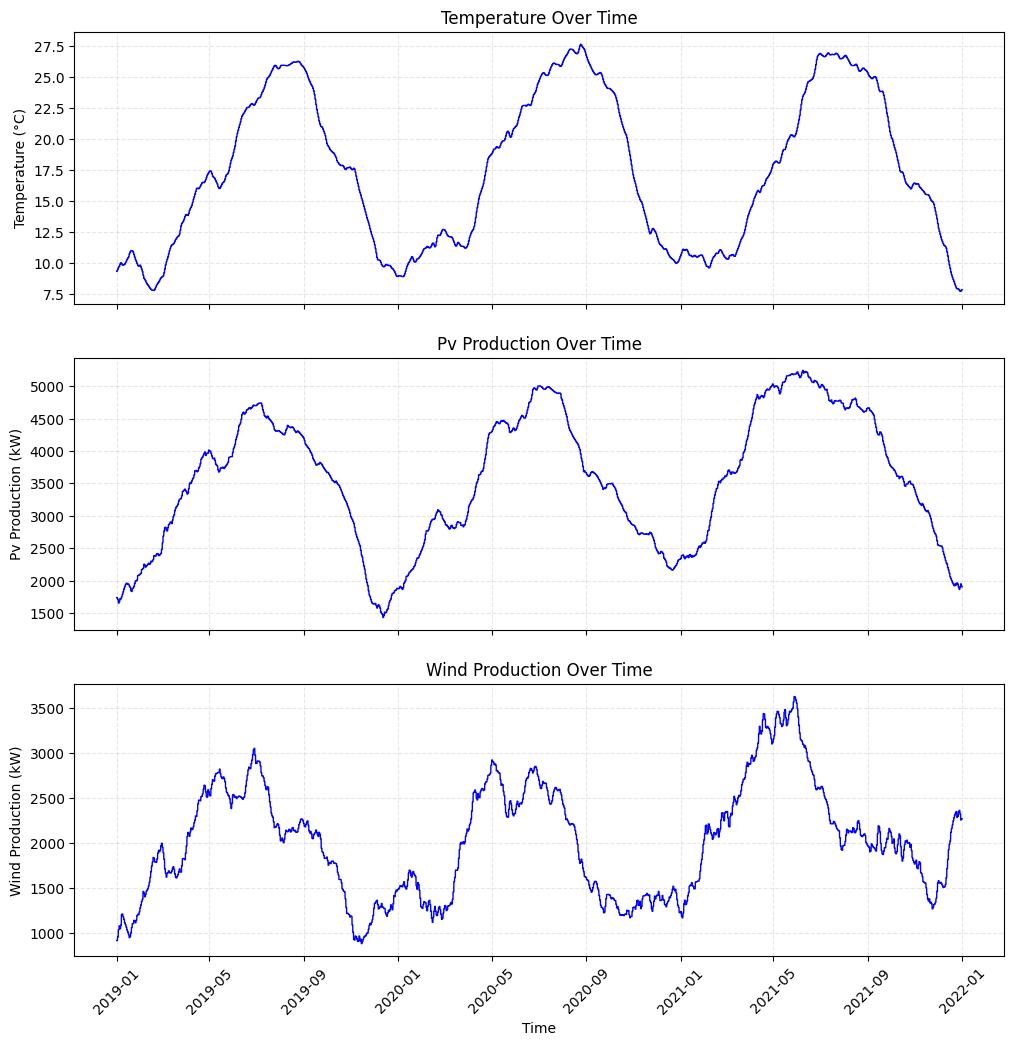

In [64]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, sharex=True, figsize=(12, 12))

# Temperature Graph
graph_data(monthly_data, 'Temperature', '°C', ax=ax1)

# Solar Power Graph
graph_data(monthly_data, 'PV_production', 'kW', ax=ax2)

# Wind Power Graph
graph_data(monthly_data, 'Wind_production', 'kW', ax=ax3)

plt.xticks(rotation=45)
ax3.set_xlabel('Time');

# Correlation Coefficients
print(f"Correlation between Temperature and PV Production: {get_correlation('Temperature', 'PV_production')}")
print(f"Correlation between Temperature and Wind Production: {get_correlation('Temperature', 'Wind_production')}")

While temperature has a positive correlation (0.62) with Solar Production, it has a small negative correlation (-0.06) between it and wind production. This shows that temperature doesn't play much of a role into wind energy but an influential role in solar energy production.

**Question 4. How does Photovoltaic Radiation change throughout Multiple Seasons?**

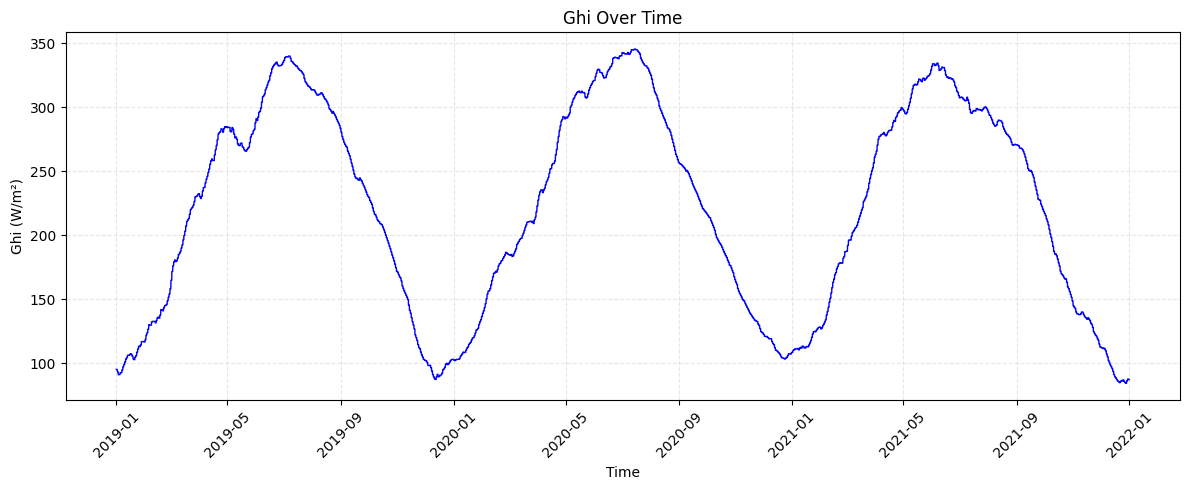

In [66]:
# GHI Graph
graph_data(monthly_data, 'GHI', 'W/m²')

We see that PV Radiation is low around the winter months and high around the summer months.

**Question 5. What Seasons Correlate with Solar and Wind Production?**

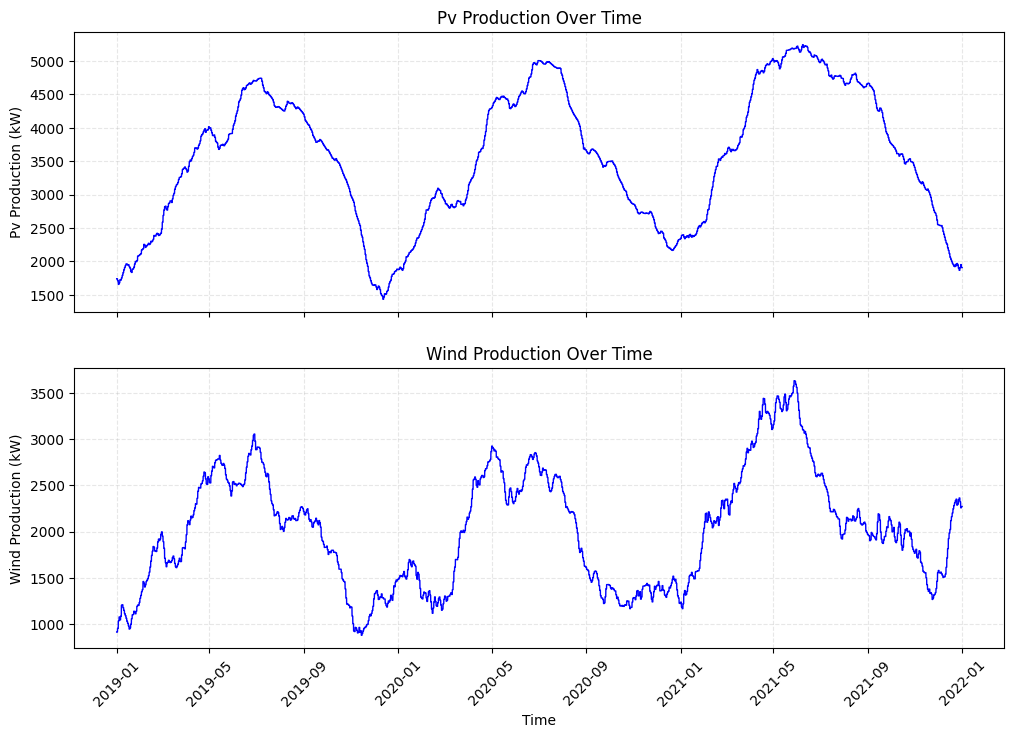

In [39]:
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(12, 8))
# Solar Power Graph
graph_data(monthly_data, 'PV_production', 'kW', ax=ax1)

# Wind Power Graph
graph_data(monthly_data, 'Wind_production', 'kW', ax=ax2)

plt.xticks(rotation=45)
ax2.set_xlabel('Time');

The graph shows that Renewables in general are more powerful in the summer months and weaker in the winter months, demonstrating the need for  other alternatives such as gas and nuclear during the winter months.

**Conclusions**

This EDA shows that while renewable sources are ideal in a zero-carbon world, some form of carbon-emitting energy sources, if not nuclear energy, has to be added, as renewable projects face physical challenges with battery storage. This is especially relevant in the winter months because renewable sources don't generate enough electricity to offset electric demand, further demonstrating the need for a mixed energy system to ensure grid stability and predictable energy for households.